# Filtering spatially

This example shows how to filter geometries in vector files spatially. This can be done using either the extractFeatures or the extractAndClipFeatures function. The extractFeatures function filters the vector data based on a given geometry, whereas the extractAndClipFeatures function clips the vector file to the given geometry. ExtractAndClipFeatures, on the other hand, clips the vector file to the given geometry.

## Import the necessary libraries

In [16]:
import geokit.core.geom
import geokit.core.vector
import geokit.core.srs
from geokit.core.get_test_data import get_test_data
import pathlib

## Filter spatially using the extract features function

This function returns a data frame containing all geometries and their attributes that touch the geometry provided in the "geom" argument. In this example, the returned geometry is the outline of the German state of North Rhine-Westphalia touched by a point located in the city of Aachen.

In [17]:
data_cache_folder = pathlib.Path().cwd().parent.parent.joinpath("geokit", "data")

path_to_shape_file = get_test_data(
    file_name="gadm36_DEU_1.shp",
    data_cache_folder=data_cache_folder,
)
# Point of Aachen
aachen_pt_real = geokit.core.geom.point((6.083, 50.775), srs=geokit.core.srs.EPSG4326)

# Filter for the federal state containing Aachen
federal_states_DE_df_geom_filtered = geokit.core.vector.extractFeatures(
    path_to_shape_file, geom=aachen_pt_real, spatialPredicate="Touches"
)
federal_states_DE_df_geom_filtered

,geom,GID_0,NAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1
0,"POLYGON ((8.05965614 50.69504166,8.0413866 50....",DEU,Germany,DEU.10_1,Nordrhein-Westfalen,North Rhine-Westphalia,None,Land,State,05,DE.NW


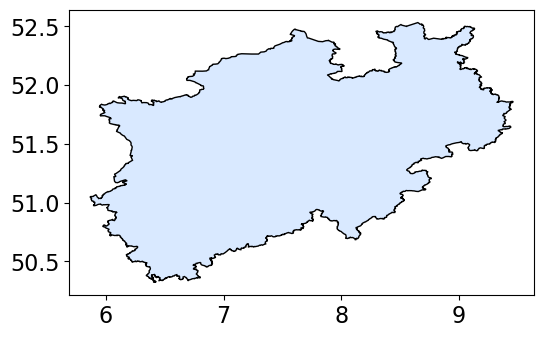

In [18]:
# plotting the results shows how the province geometries where clipped to our random box polygon shape
ax_handle_clipped = geokit.core.geom.drawGeoms(geoms=federal_states_DE_df_geom_filtered, figsize=(6, 6))

## Filtering and Clipping Spatially

A random box is defined here between 8-10° longitude and 50-52° latitude, which is in the center of Germany. The parts of the federal states within that box are returned.

In [19]:
# Path to cache folder

path_to_shape_file = get_test_data(
    file_name="gadm36_DEU_1.shp",
    data_cache_folder=data_cache_folder,
)
# instead of the point of Aachen, let us define a random square box between 8-10° lon and 50-52° lat in the center of Germany
center_box = geokit.core.geom.box((8, 50, 10, 52), srs=4326)

# now extract all "Bundeslaender" that overlap with this box AND clip their geometries to the box extent
# the parameter 'scaleAttrs' would allow to scale numeric attributes of the states linearly with area share (but we have none in the sample data)
federal_states_DE_df_geom_clipped = geokit.core.vector.extractAndClipFeatures(
    path_to_shape_file, geom=center_box, scaleAttrs=None
)

# we get the expected federal states in the center of Germany
# also note the area share of each state area that is contained in the box, Hesse is nearly completely contained
federal_states_DE_df_geom_clipped

,geom,GID_0,NAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,areaShare
0,"POLYGON Z ((9.04122543 50.00000763 0,9.0352535...",DEU,Germany,DEU.2_1,Bayern,Bavaria,None,Freistaat,None,09,DE.BY,0.025930
1,"POLYGON Z ((9.93442822 50.41932678 0,9.9342784...",DEU,Germany,DEU.7_1,Hessen,Hesse,None,Land,State,06,DE.HE,0.842050
2,"POLYGON Z ((9.99879646 51.40369415 0,9.9952554...",DEU,Germany,DEU.9_1,Niedersachsen,Lower Saxony,None,Land,State,03,DE.NI,0.052680
3,"POLYGON Z ((8.0413866 50.69665527 0,8.03969002...",DEU,Germany,DEU.10_1,Nordrhein-Westfalen,North Rhine-Westphalia,None,Land,State,05,DE.NW,0.254207
4,"MULTIPOLYGON Z (((8.00022984 50.75508118 0,8.0...",DEU,Germany,DEU.11_1,Rheinland-Pfalz,Rhineland-Palatinate,None,Land,State,07,DE.RP,0.016208
5,"MULTIPOLYGON Z (((9.99682236 50.67557526 0,9.9...",DEU,Germany,DEU.16_1,Thüringen,Thuringia,None,Freistaat,State,16,DE.TH,0.010095


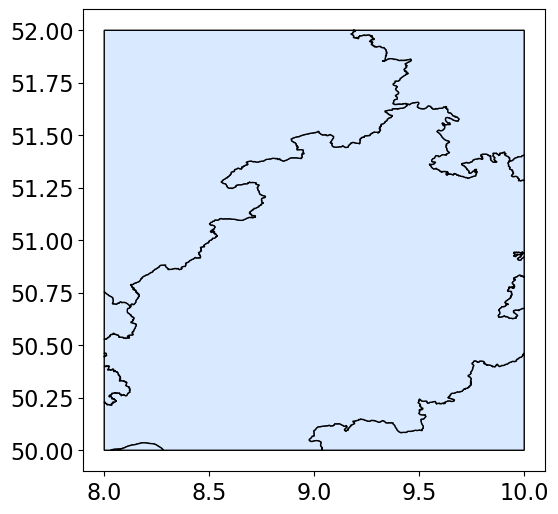

In [21]:
# plotting the results shows how the province geometries where clipped to our random box polygon shape
ax_handle_clipped = geokit.core.geom.drawGeoms(federal_states_DE_df_geom_clipped, figsize=(6, 6))